In [9]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
# Sequence Mask

def sequence_mask(
    X: torch.Tensor,
    valid_lens: torch.Tensor,
    value: float = 0.0,
) -> torch.Tensor:
    
    # X: [N, K]
    #   - N: B * Q개의 Score Row
    #   - K: key 수
    num_keys = X.shape[1]

    # [1, K]
    positions = torch.arange(
        num_keys,
        device=X.device,
    ).reshape(1, -1)

    # [1, K] < [N, 1] -> [N, K]
    mask = (
        positions
        < valid_lens.to(
            device=X.device
        ).reshape(-1, 1)
    )

    masked_X = X.clone()
    masked_X[~mask] = value

    return masked_X




# Masked Softmax

def masked_softmax(
    X: torch.Tensor,
    valid_lens: torch.Tensor | None,
) -> torch.Tensor:
    # X: [B, Q, K]

    if valid_lens is None:
        return nn.functional.softmax(
            X,
            dim=-1,
        )

    original_shape = X.shape

    if valid_lens.ndim == 1:
        # [B] -> [B * Q]
        flattened_valid_lens = (
            torch.repeat_interleave(
                valid_lens,
                repeats=original_shape[1],
            )
        )

    else:
        # [B, Q] -> [B * Q]
        flattened_valid_lens = (
            valid_lens.reshape(-1)
        )

    # [B, Q, K] -> [B * Q, K]
    flattened_X = X.reshape(
        -1,
        original_shape[-1],
    )

    masked_X = sequence_mask(
        X=flattened_X,
        valid_lens=flattened_valid_lens,
        value=-1e6,
    )

    return nn.functional.softmax(
        masked_X.reshape(original_shape),
        dim=-1,
    )

In [ ]:
# Additive Attention data flow

# [DotProductAttention]
# Query와 Key Dimension이 같아야 함
# → Query @ Keyᵀ

# [AdditiveAttention]
# Query와 Key Dimension이 달라도 됨
# → 각각 Hidden Dimension으로 변환
# → 더하고 tanh
# → Scalar Score 생성

batch_size = 2   # B
num_queries = 1  # Q
num_keys = 10    # K

query_dim = 20   # Dq
key_dim = 2      # Dk
value_dim = 4    # V
num_hiddens = 8  # H



# [B, Q, Dq] = [2, 1, 20]
queries = torch.normal(
    mean=0.0,
    std=1.0,
    size=(
        batch_size,
        num_queries,
        query_dim,
    ),
)

# [B, K, Dk] = [2, 10, 2]
keys = torch.normal(
    mean=0.0,
    std=1.0,
    size=(
        batch_size,
        num_keys,
        key_dim,
    ),
)

# [B, K, V] = [2, 10, 4]
values = torch.normal(
    mean=0.0,
    std=1.0,
    size=(
        batch_size,
        num_keys,
        value_dim,
    ),
)

valid_lens = torch.tensor([
    2,
    6,
])



# Query와 Key를 같은 Hidden dimension으로 변환
W_q = nn.LazyLinear(
    out_features=num_hiddens,
    bias=False,
)

W_k = nn.LazyLinear(
    out_features=num_hiddens,
    bias=False,
)

w_v = nn.LazyLinear(
    out_features=1,
    bias=False,
)


# Q:[B, Q, Dq] -> [B, Q, H]
projected_queries = W_q(
    queries
)

# K:[B, K, Dk] -> [B, K, H]
projected_keys = W_k(
    keys
)


# [B, Q, H] -> [B, Q, 1, H]
expanded_queries = projected_queries.unsqueeze(
    dim=2
)

# [B, K, H] -> [B, 1, K, H]
expanded_keys = projected_keys.unsqueeze(
    dim=1
)


# Broadcasting & Activation Function:
#
# expanded_queries:[B, Q, 1, H]
#                       +
# expanded_keys   :[B, 1, K, H]
# -> [B, Q, K, H]
features = torch.tanh(
    expanded_queries
    + expanded_keys
)

# [B, Q, K, H] 
# -> [B, Q, K, 1] 
# -> [B, Q, K]
scores = w_v(
    features
).squeeze(-1)


# [B, Q, K]
attention_weights = masked_softmax(
    X=scores,
    valid_lens=valid_lens,
)

# [B, Q, K] @ [B, K, V] -> [B, Q, V]
attention_output = torch.bmm(
    attention_weights,
    values,
)


print(
    "Projected Queries shape:",
    tuple(projected_queries.shape),
)
print(
    "Projected Keys shape:",
    tuple(projected_keys.shape),
)
print(
    "Expanded Queries shape:",
    tuple(expanded_queries.shape),
)
print(
    "Expanded Keys shape:",
    tuple(expanded_keys.shape),
)
print(
    "Features shape:",
    tuple(features.shape),
)
print(
    "Scores shape:",
    tuple(scores.shape),
)
print(
    "Attention Weights shape:",
    tuple(attention_weights.shape),
)
print(
    "Attention Output shape:",
    tuple(attention_output.shape),
)

Projected Queries shape: (2, 1, 8)
Projected Keys shape: (2, 10, 8)
Expanded Queries shape: (2, 1, 1, 8)
Expanded Keys shape: (2, 1, 10, 8)
Features shape: (2, 1, 10, 8)
Scores shape: (2, 1, 10)
Attention Weights shape: (2, 1, 10)
Attention Output shape: (2, 1, 4)


In [12]:
# Additive Attention

class AdditiveAttention(nn.Module):

    def __init__(
        self,
        num_hiddens: int,
        dropout: float,
    ) -> None:
        super().__init__()

        self.W_q = nn.LazyLinear(
            out_features=num_hiddens,
            bias=False,
        )

        self.W_k = nn.LazyLinear(
            out_features=num_hiddens,
            bias=False,
        )

        self.w_v = nn.LazyLinear(
            out_features=1,
            bias=False,
        )

        self.dropout = nn.Dropout(
            p=dropout
        )

        self.attention_weights: (
            torch.Tensor | None
        ) = None
        
        
    def forward(
        self,
        queries: torch.Tensor,
        keys: torch.Tensor,
        values: torch.Tensor,
        valid_lens: torch.Tensor | None = None,
    ) -> torch.Tensor:
        
        # Queries: [B, Q, Dq] -> [B, Q, H]
        projected_queries = self.W_q(
            queries
        )

        # Keys: [B, K, Dk] -> [B, K, H]
        projected_keys = self.W_k(
            keys
        )
        
        # Broadcasting & Activation function
        # [B, Q, 1, H] + [B, 1, K, H] -> [B, Q, K, H]
        features = torch.tanh(
            projected_queries.unsqueeze(2)
            + projected_keys.unsqueeze(1)
        )
        
        # [B, Q, K, H] -> [B, Q, K, 1] -> [B, Q, K]
        scores = self.w_v(
            features
        ).squeeze(-1)
        
        # Attention weights: [B, Q, K]
        self.attention_weights = (
            masked_softmax(
                X=scores,
                valid_lens=valid_lens,
            )
        )
        
        # [B, Q, K] @ [B, K, V] -> [B, Q, V]
        return torch.bmm(
            self.dropout(
                self.attention_weights
            ),
            values,
        )

In [13]:

# AdditiveAttention Test

attention = AdditiveAttention(
    num_hiddens=8,
    dropout=0.1,
)

# Evaluation Mode에서는 Dropout 비활성화
attention.eval()

output = attention(
    queries=queries,
    keys=keys,
    values=values,
    valid_lens=valid_lens,
)

print(
    "Output shape:",
    tuple(output.shape),
)

print(
    "\nOutput:"
)
print(
    output
)

d2l.check_shape(
    output,
    (
        2,
        1,
        4,
    ),
)

Output shape: (2, 1, 4)

Output:
tensor([[[-0.2503, -0.1968,  0.1244, -0.4330]],

        [[-0.3743,  0.0060, -0.2943,  0.6391]]], grad_fn=<BmmBackward0>)


Attention Weight shape: (2, 1, 10)

Batch 0 Weights:
tensor([[0.5041, 0.4959, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]], grad_fn=<SelectBackward0>)

Batch 1 Weights:
tensor([[0.1770, 0.1638, 0.2027, 0.1379, 0.1378, 0.1809, 0.0000, 0.0000, 0.0000,
         0.0000]], grad_fn=<SelectBackward0>)

Weight Sums:
tensor([[1.],
        [1.]], grad_fn=<SumBackward1>)


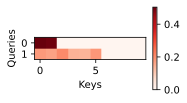

In [ ]:
# Attention Weight Validation and Heatmap

if attention.attention_weights is None:
    raise RuntimeError(
        "Attention Weights were not computed."
    )

weights = attention.attention_weights

print(
    "Attention Weight shape:",
    tuple(weights.shape),
)

print(
    "\nBatch 0 Weights:"
)
print(
    weights[0]
)

print(
    "\nBatch 1 Weights:"
)
print(
    weights[1]
)

print(
    "\nWeight Sums:"
)
print(
    weights.sum(
        dim=-1
    )
)

# Batch 0은 Key 2개만 사용
assert torch.count_nonzero(
    weights[0, :, 2:]
).item() == 0

# Batch 1은 Key 6개만 사용
assert torch.count_nonzero(
    weights[1, :, 6:]
).item() == 0

torch.testing.assert_close(
    weights.sum(dim=-1),
    torch.ones(2, 1),
)

d2l.show_heatmaps(
    weights.reshape(
        1,
        1,
        2,
        10,
    ),
    xlabel="Keys",
    ylabel="Queries",
)

